# Intro. ao Aprendizado de Máquina (ENGG67) - Avaliação 1

Professor: ANTONIO CARLOS LOPES FERNANDES JUNIOR<br>
Alunos: ANDRE NEVES DA ROCHA CASTRO e HUGO SOUZA ROCHA

##  Caracterização e Exploração Inicial

O [Heart Disease Dataset](https://archive.ics.uci.edu/ml/datasets/Heart+Disease) é um conjunto de dados que reúne informações clínicas e resultados de exames de pacientes. Os dados incluem variáveis como idade, sexo, tipo de dor no peito, pressão arterial, colesterol e resultados de testes cardíacos, permitindo análises preditivas relevantes na área da saúde.

In [10]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
heart_disease = fetch_ucirepo(id=45) 
  
X = heart_disease.data.features 
y = heart_disease.data.targets 

# Verificando as dimensões de X (preditores) e y (alvo)
n_instancias, n_atributos = X.shape
n_alvos = y.shape[1] if len(y.shape) > 1 else 1

print(f"Número de instâncias (pacientes): {n_instancias}")
print(f"Número de atributos preditivos: {n_atributos}")
print(f"Número de atributos alvo: {n_alvos}")

Número de instâncias (pacientes): 303
Número de atributos preditivos: 13
Número de atributos alvo: 1


A classificação do dataset como **multivariado** justifica-se pelo fato de que cada observação (paciente) é composta por múltiplas variáveis medidas simultaneamente (como idade, colesterol, pressão arterial, etc.), as quais, em conjunto, fornecem o contexto necessário para a predição. No contexto de Aprendizado de Máquina, identificar corretamente os **13 atributos preditivos** preditivos é essencial, pois eles representam o espaço de características que o modelo explorará para encontrar padrões. O atributo alvo (num), que indica a presença ou ausência de doença cardíaca.

### Caracterização dos Dados: Tipo e Escala

Antes de selecionar algoritmos de aprendizado de máquina ou técnicas de pré-processamento, é essencial realizar a **categorização dos dados**. Esta etapa distingue a forma como o computador armazena a informação (tipo técnico) de como o dado se comporta matematicamente (natureza estatística).

Os atributos do *dataset* são divididos em duas grandes classes:

#### 1. Atributos Qualitativos (Categóricos)
Representam qualidades ou categorias. Não possuem valor numérico intrínseco, mesmo quando codificados com números.

* **Escala Nominal** (Sem ordem intrínseca):
    * `sex`: Sexo do paciente (1 = masculino; 0 = feminino).
    * `cp`: Tipo de dor no peito (4 valores distintos).
    * `fbs`: Açúcar no sangue em jejum > 120 mg/dl (Binário: 1 ou 0).
    * `restecg`: Resultados eletrocardiográficos em repouso.
    * `exang`: Angina induzida por exercício (1 = sim; 0 = não).
    * `thal`: Diagnóstico de cintilografia (normal, defeito fixo, defeito reversível).
* **Escala Ordinal** (Possuem uma ordem ou hierarquia lógica):
    * `slope`: A inclinação do segmento ST no pico do exercício (pode ser interpretada como uma progressão de intensidade).
    * `num`: O diagnóstico de doença cardíaca (0 para ausência, 1 a 4 para níveis de severidade).

---

#### 2. Atributos Quantitativos (Numéricos)
Representam medidas reais onde as operações aritméticas (soma, média) fazem sentido.

* **Escala de Razão** (O zero é absoluto e indica ausência da medida):
    * `age`: Idade (em anos).
    * `trestbps`: Pressão arterial em repouso (mmHg).
    * `chol`: Colesterol sérico (mg/dl).
    * `thalach`: Frequência cardíaca máxima atingida.
    * `oldpeak`: Depressão de ST induzida pelo exercício (valor contínuo).
    * `ca`: Número de vasos principais coloridos por fluoroscopia (embora seja discreto/inteiro, representa uma contagem física).

In [2]:
print("Informações detalhadas das variáveis (Metadados):")
display(heart_disease.variables[['name', 'type', 'description']])

Informações detalhadas das variáveis (Metadados):


,name,type,description
0,age,Integer,None
1,sex,Categorical,None
2,cp,Categorical,None
3,trestbps,Integer,resting blood pressure (on admission to the ho...
4,chol,Integer,serum cholestoral
5,fbs,Categorical,fasting blood sugar > 120 mg/dl
6,restecg,Categorical,None
7,thalach,Integer,maximum heart rate achieved
8,exang,Categorical,exercise induced angina
9,oldpeak,Integer,ST depression induced by exercise relative to ...


### Balanceamento e Estatística Univariada

Esta seção verifica o balanceamento das classes e calcula as estatísticas univariadas pertinentes para cada atributo.

#### Verificação de Balanceamento

Analisa a distribuição das classes para identificar desbalanceamento.

In [3]:
print("Distribuição das classes no atributo alvo:")
counts  = y.value_counts()
percent = counts / len(y) * 100

resumo_classes = pd.DataFrame({
    'Contagem':      counts,
    'Percentual (%)': percent.round(2)
})
display(resumo_classes)

razao = counts.max() / counts.min()
print(f"\nRazão maior/menor classe: {razao:.2f}")
print("⚠ Dataset desbalanceado — a classe 0 concentra mais da metade das instâncias enquanto a classe 4 representa menos de 5%.")

Distribuição das classes no atributo alvo:


,Contagem,Percentual (%)
num,,
0,164,54.13
1,55,18.15
2,36,11.88
3,35,11.55
4,13,4.29



Razão maior/menor classe: 12.62
⚠ Dataset desbalanceado — a classe 0 concentra mais da metade das instâncias enquanto a classe 4 representa menos de 5%.


#### Caracterização Estatística

Os atributos categóricos (como `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope` e `thal`) não devem ser analisados por medidas como média e mediana, pois essas estatísticas não são apropriadas para variáveis nominais. Para esses atributos, a análise mais adequada é por meio de tabelas de frequência e identificação da moda (valor mais frequente), permitindo entender a distribuição das categorias no conjunto de dados.

##### Atributos Categóricos — Frequência e Moda

In [4]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in categorical_cols:
    freq    = X[col].value_counts()
    percent = X[col].value_counts(normalize=True) * 100
    moda    = X[col].mode()[0]

    tabela = pd.DataFrame({
        'Frequência':     freq,
        'Percentual (%)': percent.round(2)
    })

    print(f"\n{'='*45}")
    print(f"Atributo: {col}   |   Moda: {moda}")
    print('='*45)
    
    display(tabela)


Atributo: sex   |   Moda: 1


,Frequência,Percentual (%)
sex,,
1,206,67.99
0,97,32.01



Atributo: cp   |   Moda: 4


,Frequência,Percentual (%)
cp,,
4,144,47.52
3,86,28.38
2,50,16.50
1,23,7.59



Atributo: fbs   |   Moda: 0


...

,Frequência,Percentual (%)
exang,,
0,204,67.33
1,99,32.67



Atributo: slope   |   Moda: 1


,Frequência,Percentual (%)
slope,,
1,142,46.86
2,140,46.20
3,21,6.93



Atributo: thal   |   Moda: 3.0


,Frequência,Percentual (%)
thal,,
3.0,166,55.15
7.0,117,38.87
6.0,18,5.98


##### Atributos Numéricos — Estatísticas Descritivas

Para os atributos quantitativos, são calculadas média, mediana, moda, desvio-padrão, Q1, Q3, obliquidade e curtose. O atributo `ca`, embora listado como `Integer` nos metadados, foi incluído nesta análise por representar uma contagem física (número de vasos), o que lhe confere natureza de escala de razão — coerente com a categorização apresentada na seção anterior.

In [5]:
from scipy.stats import skew, kurtosis

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

stats = pd.DataFrame(index=numerical_cols)
stats['Média']       = X[numerical_cols].mean()
stats['Mediana']     = X[numerical_cols].median()
stats['Moda']        = X[numerical_cols].mode().iloc[0]
stats['Desvio-Pad.'] = X[numerical_cols].std()
stats['Q1']          = X[numerical_cols].quantile(0.25)
stats['Q3']          = X[numerical_cols].quantile(0.75)
stats['Obliquidade'] = X[numerical_cols].apply(lambda col: skew(col.dropna()))
stats['Curtose']     = X[numerical_cols].apply(lambda col: kurtosis(col.dropna()))

pd.options.display.float_format = '{:.4f}'.format
display(stats.round(4))

,Média,Mediana,Moda,Desvio-Pad.,Q1,Q3,Obliquidade,Curtose
age,54.4389,56.0000,58.0000,9.0387,48.0000,61.0000,-0.2080,-0.5345
trestbps,131.6898,130.0000,120.0000,17.5997,120.0000,140.0000,0.7025,0.8459
chol,246.6931,241.0000,197.0000,51.7769,211.0000,275.0000,1.1299,4.3982
thalach,149.6073,153.0000,162.0000,22.8750,133.5000,166.0000,-0.5348,-0.0724
oldpeak,1.0396,0.8000,0.0000,1.1611,0.0000,1.6000,1.2634,1.5302
ca,0.6722,0.0000,0.0000,0.9374,0.0000,1.0000,1.1834,0.2349


### Qualidade dos Dados

Esta seção analisa o dataset quanto a incompletude, inconsistências, redundâncias e presença de ruído.

#### Incompletude — Valores Ausentes

In [6]:
ausentes = X.isnull().sum()
percent_ausentes = ausentes / len(X) * 100

incompletude = pd.DataFrame({
    'Valores Ausentes': ausentes,
    'Percentual (%)': percent_ausentes.round(2)
})
incompletude = incompletude[incompletude['Valores Ausentes'] > 0]

if incompletude.empty:
    print("Nenhum valor ausente encontrado nos atributos preditivos.")
else:
    print("Atributos com valores ausentes:")
    display(incompletude)

Atributos com valores ausentes:


,Valores Ausentes,Percentual (%)
ca,4,1.3200
thal,2,0.6600


Os atributos preditivos `ca` e `thal` apresentam valores ausentes — 4 e 2 instâncias respectivamente — o que representa menos de 2% do total. Dado o volume reduzido, esses casos podem ser tratados por imputação (média ou moda) ou simplesmente removidos sem comprometer a representatividade do conjunto.

#### Inconsistências — Valores Fora do Domínio

Verifica se os atributos apresentam valores impossíveis ou fora do intervalo esperado para o domínio clínico.

In [7]:
checks = {
    # Verificação de limites físicos/biológicos para variáveis numéricas
    'age':      (X['age']      < 0)  | (X['age']      > 120), # Idade fora de 0-120
    'trestbps': (X['trestbps'] < 0)  | (X['trestbps'] > 300), # Pressão arterial irreal
    'chol':      (X['chol']      < 0)  | (X['chol']      > 600), # Colesterol extremo
    'thalach':  (X['thalach']  < 0)  | (X['thalach']  > 250), # Frequência cardíaca máxima
    'oldpeak':  (X['oldpeak']  < 0)  | (X['oldpeak']  > 10),  # Depressão de ST
    'ca':        (X['ca']        < 0)  | (X['ca']        > 3),   # Número de vasos (0-3)

    # O operador '~' (not) seleciona o que NÃO está na lista permitida.
    'sex':      ~X['sex'].isin([0, 1]),            # 0=fem, 1=masc
    'fbs':      ~X['fbs'].isin([0, 1]),            # Açúcar no sangue (binário)
    'exang':    ~X['exang'].isin([0, 1]),          # Angina induzida (binário)
    'cp':       ~X['cp'].isin([1, 2, 3, 4]),       # Tipos de dor (1 a 4)
    'restecg':  ~X['restecg'].isin([0, 1, 2]),     # Eletrocardiograma (0 a 2)
    'slope':    ~X['slope'].isin([1, 2, 3]),       # Inclinação ST (1 a 3)
    'thal':     ~X['thal'].isin([3, 6, 7]),        # Resultados de talassemia (3, 6, 7)
}

inconsistencias = []

for col, mascara in checks.items():
    n_erros = mascara.sum() # Soma os valores True (que representam inconsistências)
    if n_erros > 0:
        inconsistencias.append({'Atributo': col, 'Ocorrências': n_erros})

if not inconsistencias:
    print("Sucesso: Nenhuma inconsistência de domínio encontrada.")
else:
    print("Alerta: Atributos com valores fora do domínio esperado:")
    df_erros = pd.DataFrame(inconsistencias).set_index('Atributo')
    display(df_erros)

Alerta: Atributos com valores fora do domínio esperado:


,Ocorrências
Atributo,
thal,2


Foram identificadas 2 ocorrências inconsistentes no atributo `thal`, cujos valores não pertencem ao domínio esperado (3.0, 6.0 ou 7.0). Isso é coerente com os 2 valores ausentes detectados na etapa anterior — o `ucimlrepo` pode estar preenchendo registros faltantes com um valor sentinela inválido. Essas instâncias devem ser tratadas como valores ausentes e receber o mesmo tratamento definido para a incompletude: imputação pela moda (3.0) ou remoção das linhas afetadas.

#### Redundâncias — Instâncias Duplicadas e Atributos Correlacionados

Instâncias duplicadas: 0

Matrix de correlação (atributos numéricos):


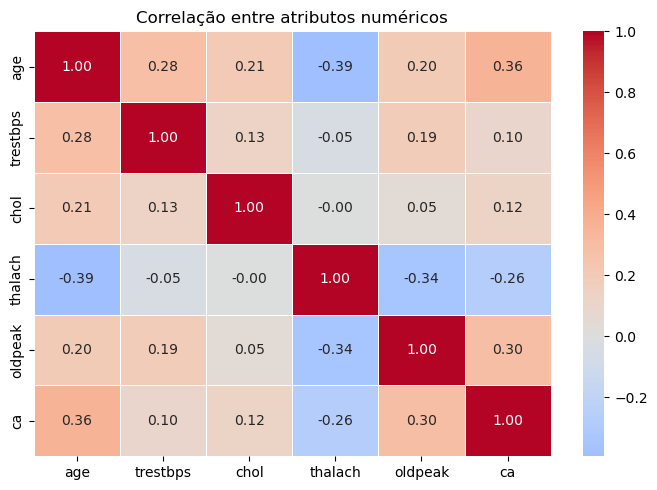


Nenhum par de atributos com correlação acima de 0.8.


In [8]:
n_duplicatas = X.duplicated().sum()
print(f"Instâncias duplicadas: {n_duplicatas}")

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
corr = X[numerical_cols].corr()

print("\nMatrix de correlação (atributos numéricos):")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlação entre atributos numéricos')
plt.tight_layout()
plt.show()

pares_altos = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            pares_altos.append({
                'Atributo 1': corr.columns[i],
                'Atributo 2': corr.columns[j],
                'Correlação': round(r, 4)
            })

if not pares_altos:
    print("\nNenhum par de atributos com correlação acima de 0.8.")
else:
    print("\nPares com alta correlação (|r| > 0.8):")
    display(pd.DataFrame(pares_altos))

Não foram encontradas instâncias duplicadas no dataset. A matriz de correlação entre os atributos numéricos não revelou nenhum par com correlação acima de 0.8, indicando ausência de redundância linear expressiva. Em geral, as correlações são moderadas ou fracas, sem nenhum par que indique redundância que justifique a remoção de atributos nesta etapa.

#### Ruído — Detecção de Outliers

Utiliza o critério do IQR (intervalo interquartil) para identificar possíveis outliers nos atributos numéricos.

,Lim. Inf.,Lim. Sup.,Outliers,% do total
Atributo,,,,
age,28.5000,80.5000,0,0.0000
trestbps,90.0000,170.0000,9,2.9700
chol,115.0000,371.0000,5,1.6500
thalach,84.7500,214.7500,1,0.3300
oldpeak,-2.4000,4.0000,5,1.6500
ca,-1.5000,2.5000,20,6.6000


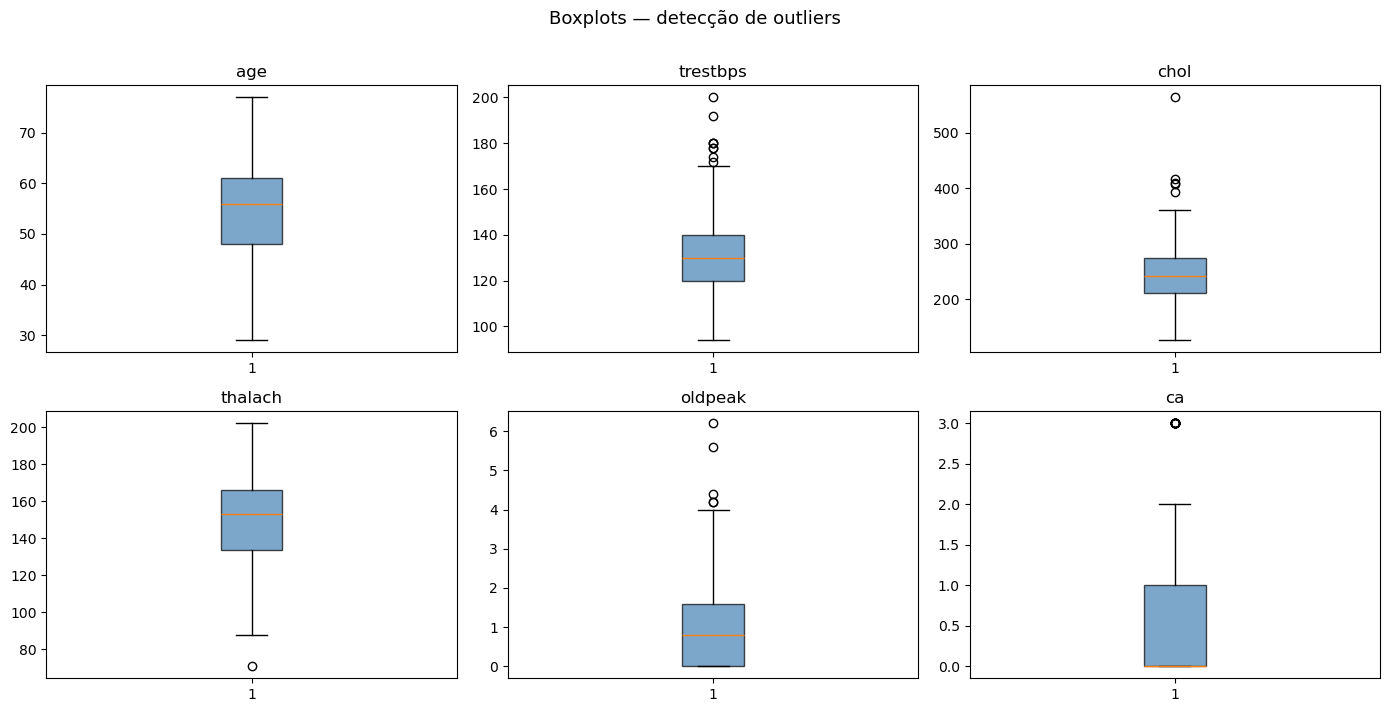

In [9]:
outlier_resumo = []

for col in numerical_cols:
    Q1  = X[col].quantile(0.25)
    Q3  = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((X[col] < lim_inf) | (X[col] > lim_sup)).sum()
    outlier_resumo.append({
        'Atributo':   col,
        'Lim. Inf.':  round(lim_inf, 2),
        'Lim. Sup.':  round(lim_sup, 2),
        'Outliers':   n_outliers,
        '% do total': round(n_outliers / len(X) * 100, 2)
    })

resumo_df = pd.DataFrame(outlier_resumo).set_index('Atributo')
display(resumo_df)

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(X[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — detecção de outliers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

A análise pelo critério IQR identificou a presença de outliers em todos os atributos numéricos, com destaque para `ca`, `chol` e `trestbps`, que apresentam os maiores percentuais de valores extremos. Os boxplots confirmam a assimetria positiva observada nas estatísticas univariadas. Esses outliers não necessariamente representam erros de medição — no contexto clínico, valores extremos de colesterol ou pressão arterial são clinicamente possíveis e potencialmente relevantes para a predição. Recomenda-se investigar caso a caso antes de qualquer remoção.